3. **Métricas** — pacote interno `scripts.metrics` (Text ED, Reading Order, TEDS, CDM, Overall)

In [ ]:
# Configuração de caminhos — garante imports do backend e do pacote de métricas
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT.name != "acessilia" and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))

print("Repo root:", REPO_ROOT)

Repo root: /Users/akira/dados/sync/dev/acessilia


In [28]:
# Força recarga do módulo toolbox_client (método sync_dataset foi adicionado)
import importlib
import backend.tools.toolbox_client
importlib.reload(backend.tools.toolbox_client)
print("toolbox_client recarregado")

toolbox_client recarregado


## 0. Saúde da Toolbox

Verifica se a Toolbox está acessível e quais capacidades/datasets ela expõe.

In [29]:
import asyncio
from backend.tools.toolbox_client import ToolboxClient

async def check():
    client = ToolboxClient()
    try:
        health = await client.health()
        print("Health:", health)
        caps = await client.capabilities()
        print(f"\nCapacidades ({len(caps)}):")
        for c in caps:
            print(" -", c.get("id") if isinstance(c, dict) else c)
        datasets = await client.list_datasets()
        print(f"\nDatasets: {[d.get('id') for d in datasets]}")
    finally:
        await client.close()

await check()

Health: {'status': 'healthy', 'version': '0.1.0'}

Capacidades (21):
 - accessibility.mark
 - artifact.retrieve
 - artifact.store
 - code.normalize
 - dataset.describe
 - dataset.get_artifact
 - dataset.get_item
 - dataset.list
 - dataset.list_items
 - dataset.list_splits
 - dataset.sample
 - dataset.sync
 - document.layout.analyze
 - document.ocr
 - document.structure.extract
 - math.convert
 - math.recognize
 - math.verbalize
 - pdf.render
 - pdf.split
 - text.postprocess

Datasets: ['acessilia-dataset', 'dr-docbench']


## 1. Dataset Dr.DocBench

O dataset está registrado na Toolbox como `dr-docbench` (fonte HuggingFace `2077AIDataFoundation/DrDocBench`). Cada **item = 1 página** (`{doc_uuid}_p{N}`), organizado em 52 assuntos BISAC. No split `dev`, cada item traz anotações: OmniDocJSON **e** ground-truth markdown (`mds/..._page_N.md`).

In [27]:
from backend.tools.toolbox_client import ToolboxClient

# Re-mirror dos artefatos do dataset Dr.DocBench para o store local da Toolbox.
# Rota REST: POST /v1/datasets/{id}/sync (pode demorar — baixa ~1500 páginas).
client = ToolboxClient()
try:
    result = await client.sync_dataset("dr-docbench")
    print("Sync OK —", len(result) if isinstance(result, list) else result)
finally:
    await client.close()

2026-09-15 04:21:05.944 | INFO     | backend.tools.toolbox_client:sync_dataset:253 - Toolbox: dataset dr-docbench sincronizado


Sync OK — 1004


In [30]:
from backend.tools.toolbox_dataset_tools import DATASET_ID
from backend.tools.toolbox_client import ToolboxClient

# Lista as 10 primeiras páginas do split dev usando await (notebook com event loop)
client = ToolboxClient()
try:
    items = await client.list_items(DATASET_ID, "dev", limit=10)
finally:
    await client.close()

print(f"Dataset: {DATASET_ID} — {len(items)} itens recuperados\n")
for it in items:
    meta = it.get("metadata", {})
    print(f"  {it.get('id')}: subject={meta.get('subject')!r}, doc={meta.get('document')}, page={meta.get('page')}")

Dataset: dr-docbench — 10 itens recuperados

  adf0ea9c-f744-4f64-9f74-66a9d276f371_p32: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=32
  adf0ea9c-f744-4f64-9f74-66a9d276f371_p33: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=33
  adf0ea9c-f744-4f64-9f74-66a9d276f371_p34: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=34
  adf0ea9c-f744-4f64-9f74-66a9d276f371_p35: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=35
  adf0ea9c-f744-4f64-9f74-66a9d276f371_p36: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=36
  adf0ea9c-f744-4f64-9f74-66a9d276f371_p37: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=37
  adf0ea9c-f744-4f64-9f74-66a9d276f371_p38: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=38
  adf0ea9c-f744-4f64-9f74-66a9d276f371_p39: subject='ARCHITECTURE', doc=adf0ea9c-f744-4f64-9f74-66a9d276f371, page=39
  adf0ea9c-

In [31]:
# Inspeciona um item completo: refs de imagem e anotações (GT)
client = ToolboxClient()
try:
    item = await client.get_item(DATASET_ID, "dev", items[0]["id"])
finally:
    await client.close()

print("Artifacts (entrada):")
for ref in item.get("artifacts", []):
    print(f"  {ref.get('path')}  [{ref.get('media_type')}]")
print("\nAnnotations (ground truth, só no dev):")
for ref in item.get("annotations", []):
    print(f"  {ref.get('path')}  [{ref.get('media_type')}]")

Artifacts (entrada):
  dev/ARCHITECTURE/adf0ea9c-f744-4f64-9f74-66a9d276f371/images/page_32.jpg  [image/jpeg]

Annotations (ground truth, só no dev):
  dev/ARCHITECTURE/adf0ea9c-f744-4f64-9f74-66a9d276f371/json/adf0ea9c-f744-4f64-9f74-66a9d276f371_page_32.json  [application/json]
  dev/ARCHITECTURE/adf0ea9c-f744-4f64-9f74-66a9d276f371/mds/adf0ea9c-f744-4f64-9f74-66a9d276f371_32.md  [text/markdown]


## 2. Baixar página de exemplo

`download_drbench_page` salva a imagem da página localmente em `var/drbench/dev/`.

Imagem salva em: /Users/akira/dados/sync/dev/acessilia/var/drbench/dev/adf0ea9c-f744-4f64-9f74-66a9d276f371_p32_page_32.jpg


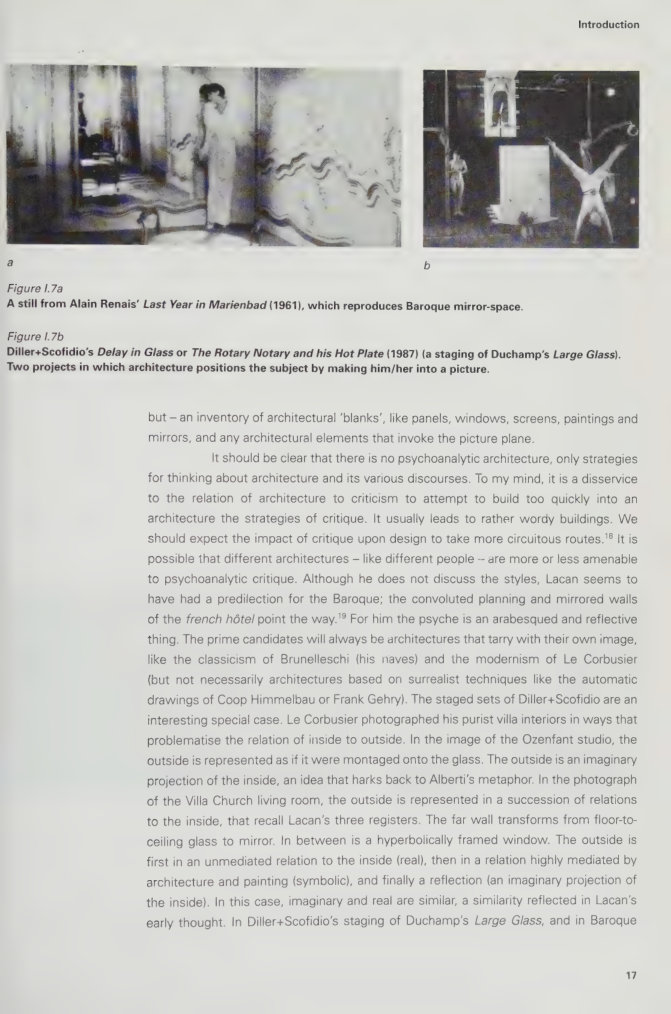

In [32]:
from backend.tools.toolbox_client import ToolboxClient
from scripts.drbench.page_record import DrBenchPage
from pathlib import Path

item_id = items[0]["id"]

# Baixa a imagem via ToolboxClient direto (await)
client = ToolboxClient()
try:
    item = await client.get_item(DATASET_ID, "dev", item_id)
    image_ref = next(
        (r for r in item.get("artifacts", []) if str(r.get("media_type", "")).startswith("image/")),
        None,
    )
    if image_ref:
        data = await client.get_dataset_artifact(DATASET_ID, "dev", item_id, image_ref["path"])
finally:
    await client.close()

out_dir = REPO_ROOT / "var" / "drbench" / "dev"
out_dir.mkdir(parents=True, exist_ok=True)
image_path = out_dir / f"{item_id}_{Path(image_ref['path']).name}" if image_ref else None
if data and image_path:
    image_path.write_bytes(data)
    print("Imagem salva em:", image_path)
else:
    print("Falha ao baixar imagem")

# Visualiza a página original
from IPython.display import Image as IPyImage, display
display(IPyImage(filename=str(image_path), width=500))

## 3. Pipeline: imagem → capability → árvore canônica → *.drbench.md

Executa a capability `document.structure.extract` (provider default: docling-serve) e converte o payload para a árvore canônica do Acessilia (`build_canonical_document`), depois para markdown benchmark. Para testar outro fornecedor: `run_page(page, provider="...")`.

In [33]:
import time
import importlib
import scripts.drbench.run_pipeline
importlib.reload(scripts.drbench.run_pipeline)  # pega correções recentes do módulo

from scripts.drbench.run_pipeline import run_page, provider_payload_to_canonical
from scripts.drbench.markdown_converter import canonical_to_drbench_md
from scripts.drbench.page_record import DrBenchPage

page = DrBenchPage.from_item_id(item_id, split="dev", subject=items[0].get("metadata", {}).get("subject", ""))
page.image_path = image_path

out_dir = REPO_ROOT / "var" / "drbench" / "predictions"
out_path = run_page(page, out_dir=out_dir)
print("Predição:", out_path)

2026-09-15 04:22:40.751 | INFO     | backend.tools.toolbox_client:extract_structure:194 - Toolbox: extração concluída (34520 ms, provider=docling)


[OK] adf0ea9c-f744-4f64-9f74-66a9d276f371_p32 (0.4s) -> adf0ea9c-f744-4f64-9f74-66a9d276f371_p32.drbench.md
Predição: /Users/akira/dados/sync/dev/acessilia/var/drbench/predictions/adf0ea9c-f744-4f64-9f74-66a9d276f371_p32.drbench.md


In [34]:
# Passo a passo do pipeline para INSPEÇÃO (sem rodar tudo de novo):

# 3a. Chama a capability e obtém o payload do provider
import asyncio
from backend.tools.toolbox_client import ToolboxClient

async def _extract():
    client = ToolboxClient()
    try:
        return await client.extract_structure(file_path=image_path)
    finally:
        await client.close()

payload = await _extract()
print("Provider:", payload.get("provider"), "| status:", payload.get("status"))

# 3b. Payload → árvore canônica
canonical = provider_payload_to_canonical(payload)
print(f"\nÁrvore canônica: {len(canonical['sections'])} sections raiz, title={canonical['title']!r}")

# 3c. Canônica → markdown benchmark
markdown = canonical_to_drbench_md(canonical)
print(f"\nMarkdown gerado ({len(markdown)} chars):\n")
print(markdown[:1500])

2026-09-15 04:22:57.243 | INFO     | backend.tools.toolbox_client:extract_structure:194 - Toolbox: extração concluída (34520 ms, provider=docling)


Provider: docling | status: succeeded

Árvore canônica: 0 sections raiz, title='Dr.DocBench page'

Markdown gerado (19 chars):

# Dr.DocBench page



## 4. Ground truth

Baixa o markdown de referência do split dev e compara lado a lado com a predição.

In [35]:
from backend.tools.toolbox_client import ToolboxClient

# Localiza a annotation markdown do item
gt_ref = next(
    (r for r in item.get("annotations", []) if str(r.get("media_type", "")).startswith("text/markdown")),
    None,
)
if gt_ref:
    client = ToolboxClient()
    try:
        gt_bytes = await client.get_dataset_artifact(DATASET_ID, "dev", item_id, gt_ref["path"])
    finally:
        await client.close()
    gt_dir = REPO_ROOT / "var" / "drbench" / "dev"
    gt_dir.mkdir(parents=True, exist_ok=True)
    gt_path = gt_dir / f"{item_id}.md"
    gt_path.write_bytes(gt_bytes)
    print("GT salvo em:", gt_path, f"({len(gt_bytes)} chars)\n")
    print(gt_bytes.decode("utf-8")[:1500])
else:
    print("Item sem annotation markdown (só existe no split dev).")

GT salvo em: /Users/akira/dados/sync/dev/acessilia/var/drbench/dev/adf0ea9c-f744-4f64-9f74-66a9d276f371_p32.md (2811 chars)

![](./imgs/adf0ea9c-f744-4f64-9f74-66a9d276f371_page_32_3.jpg)

![](./imgs/adf0ea9c-f744-4f64-9f74-66a9d276f371_page_32_9.jpg)

*Figure 1.7a*
\textbf{A still from Alain Renais' *Last Year in Marienbad* (1961), which reproduces Baroque mirror-space.}





*Figure 1.7b*
\textbf{Diller+Scofidio's *Delay in Glass or The Rotary Notary and his Hot Plate* (1987) (a staging of Duchamp's *Large Glass*).
**Two projects in which architecture positions the subject by making him/her into a picture.**





but - an inventory of architectural 'blanks', like panels, windows, screens, paintings and mirrors, and any architectural elements that invoke the picture plane.





 It should be clear that there is no psychoanalytic architecture, only strategies for thinking about architecture and its various discourses. To my mind, it is a disservice to the relation of architecture to cr

## 5. Métricas (pacote interno `scripts.metrics`)

In [ ]:
from scripts.metrics import (
    text_ed, reading_order_score, teds_score, cdm_score,
    PageScores, overall_score,
)

Item: adf0ea9c-f744-4f64-9f74-66a9d276f371_p32
  Text ED       : 0.994  (menor = melhor)
  Reading Order : 0.6
  TEDS          : n/a (sem tabela nos dois lados)
  CDM           : n/a (sem fórmula nos dois lados)
  Overall       : 0.6


## 6. Lote: 10 páginas + baseline no tracking.csv

Roda a amostra completa (fase de verificação do MVP) e depois avalia. Alternativa via terminal:

```bash
python -m scripts.drbench.run_pipeline --split dev --sample 10
python -m scripts.drbench.eval_run \
    --predictions var/drbench/predictions \
    --gt-dir var/drbench/dev --provider docling
```

In [37]:
from backend.tools.toolbox_client import ToolboxClient
from pathlib import Path

out_dir.mkdir(parents=True, exist_ok=True)
gt_dir.mkdir(parents=True, exist_ok=True)

ok = 0
for it in items:
    iid = it["id"]
    client = ToolboxClient()
    try:
        it_full = await client.get_item(DATASET_ID, "dev", iid)
        image_ref = next(
            (r for r in it_full.get("artifacts", []) if str(r.get("media_type", "")).startswith("image/")),
            None,
        )
        if image_ref is None:
            print(f"[SKIP] {iid}: sem imagem")
            continue
        img_data = await client.get_dataset_artifact(DATASET_ID, "dev", iid, image_ref["path"])
    finally:
        await client.close()

    img_path = out_dir / f"{iid}_{Path(image_ref['path']).name}"
    img_path.write_bytes(img_data)

    p = DrBenchPage.from_item_id(iid, split="dev",
                                 subject=it.get("metadata", {}).get("subject", ""))
    p.image_path = img_path
    if run_page(p, out_dir=out_dir):
        ok += 1

    # baixa GT correspondente para o eval
    gt_ref_i = next(
        (r for r in it_full.get("annotations", []) if str(r.get("media_type", "")).startswith("text/markdown")),
        None,
    )
    if gt_ref_i:
        client2 = ToolboxClient()
        try:
            gt_b = await client2.get_dataset_artifact(DATASET_ID, "dev", iid, gt_ref_i["path"])
        finally:
            await client2.close()
        (gt_dir / f"{iid}.md").write_bytes(gt_b)

print(f"\nProcessadas: {ok}/{len(items)}")

2026-09-15 04:23:56.797 | INFO     | backend.tools.toolbox_client:extract_structure:194 - Toolbox: extração concluída (34520 ms, provider=docling)


[OK] adf0ea9c-f744-4f64-9f74-66a9d276f371_p32 (0.1s) -> adf0ea9c-f744-4f64-9f74-66a9d276f371_p32.drbench.md


2026-09-15 04:24:55.982 | INFO     | backend.tools.toolbox_client:extract_structure:194 - Toolbox: extração concluída (38483 ms, provider=docling)


[OK] adf0ea9c-f744-4f64-9f74-66a9d276f371_p33 (38.7s) -> adf0ea9c-f744-4f64-9f74-66a9d276f371_p33.drbench.md


2026-09-15 04:25:31.841 | INFO     | backend.tools.toolbox_client:extract_structure:194 - Toolbox: extração concluída (12075 ms, provider=docling)


...

[OK] adf0ea9c-f744-4f64-9f74-66a9d276f371_p39 (14.2s) -> adf0ea9c-f744-4f64-9f74-66a9d276f371_p39.drbench.md


2026-09-15 04:29:39.336 | INFO     | backend.tools.toolbox_client:extract_structure:194 - Toolbox: extração concluída (14100 ms, provider=docling)


[OK] adf0ea9c-f744-4f64-9f74-66a9d276f371_p40 (14.4s) -> adf0ea9c-f744-4f64-9f74-66a9d276f371_p40.drbench.md


2026-09-15 04:30:26.747 | INFO     | backend.tools.toolbox_client:extract_structure:194 - Toolbox: extração concluída (22267 ms, provider=docling)


[OK] adf0ea9c-f744-4f64-9f74-66a9d276f371_p41 (23.3s) -> adf0ea9c-f744-4f64-9f74-66a9d276f371_p41.drbench.md

Processadas: 10/10


In [38]:
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "scripts.drbench.eval_run",
     "--predictions", str(REPO_ROOT / "var" / "drbench" / "predictions"),
     "--gt-dir", str(REPO_ROOT / "var" / "drbench" / "dev"),
     "--provider", "docling-mvp",
     "--report", str(REPO_ROOT / "var" / "drbench" / "reports" / "baseline.json")],
    capture_output=True, text=True, cwd=REPO_ROOT,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

{
  "text_ed": 1.8439835939451021,
  "reading_order": 1.876248576727032,
  "overall": 1.8601160853360668
}
Report saved to /Users/akira/dados/sync/dev/acessilia/var/drbench/reports/baseline.json; tracking at /Users/akira/dados/sync/dev/acessilia/var/drbench/reports/tracking.csv



## 7. Submissão (quando o baseline estiver aceitável)

```bash
python -m scripts.drbench.build_submission
# → var/drbench/submission/submission.zip (predictions.jsonl + mds/)
```

## Próximos ciclos

| Prioridade | Ação | Métrica alvo |
|---|---|---|
| 1 | Analisar piores páginas no relatório por componente | Overall |
| 2 | Tabelas: melhorar extração/refinar conversor table_ast | TEDS |
| 3 | Fórmulas: `math.recognize` dedicado | CDM |
| 4 | Colunas multi-coluna: heurística de reading order | Reading Order |
| 5 | Novos providers (MinerU, PaddleOCR, Surya) no benchmark | — |

Consulte o tracking: `var/drbench/reports/tracking.csv` (uma linha por ciclo/provider).